# Telco Customer Churn — Exploratory Data Analysis

**Day 1.** The goal here is to understand the data *before* we model it: how big it is, what the columns mean, whether anything is missing or oddly typed, and which features look related to churn.

In [1]:
import sys
from pathlib import Path

# Make the `src` package importable from inside the notebook
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = load_raw_data()
print("shape:", df.shape)
df.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Your task 1 — dataset overview

In the cell below, write code that prints:
1. `df.info()`  (dtypes and non-null counts)
2. the number of missing values per column: `df.isna().sum()`
3. summary statistics for the numeric columns: `df.describe()`

Then look closely at the `TotalCharges` column. What dtype is it, and is that what you'd expect for a money column? Write a one-line comment with what you notice.

In [4]:
# TODO (task 1): dataset overview — info, missing values, describe
df.info()
df.isna().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Your task 2 — churn distribution

The target column is `Churn` (values `Yes`/`No`). Write code that:
1. prints the value counts of `Churn`, both raw and as percentages
2. draws a bar plot of `Churn`

Hints: `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`, `sns.countplot(x='Churn', data=df)`.

How balanced are the two classes? This matters a lot for how we evaluate models later.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


<Axes: xlabel='Churn', ylabel='count'>

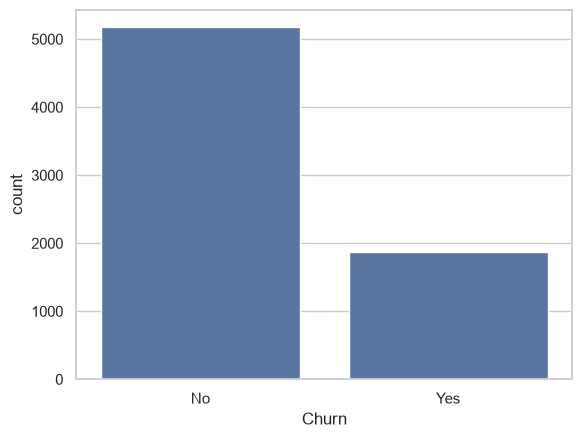

In [7]:
# TODO (task 2): churn distribution — counts + bar plot
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize = True))
sns.countplot(x = 'Churn', data = df)

## Your task 3 — churn vs. contract type

`Contract` (month-to-month / one year / two year) is usually one of the strongest churn signals. Draw a count plot of `Contract` split by churn.

Hint: `sns.countplot(x='Contract', hue='Churn', data=df)`.

Write one sentence below describing the pattern you see.

<Axes: xlabel='Contract', ylabel='count'>

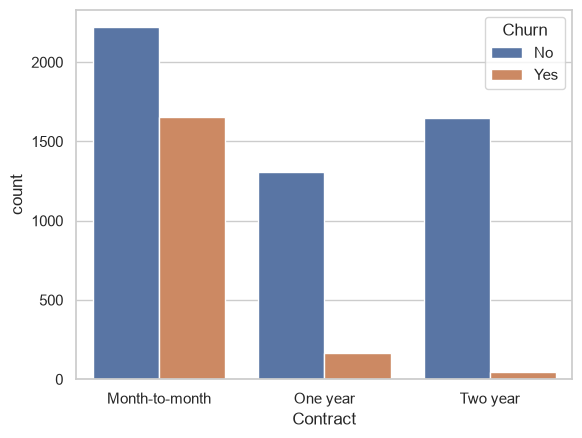

In [8]:
# TODO (task 3): churn vs. contract type plot
sns.countplot(x = 'Contract', hue = 'Churn', data = df)